# ResNet walk-through

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TXSTCODEPLAYGROUND/CodeCS4337Fall2026/blob/main/ResNetWalkThrough/ResNetWalkThrough.ipynb)

**ResNet** ([He et al., 2015, *Deep Residual Learning for Image Recognition*](https://arxiv.org/abs/1512.03385)) made very deep convolutional networks trainable with one idea: every block adds its input back to its output (a **skip connection**), so a block only has to learn a correction, and the gradient has a direct path back through the network. This notebook does not train anything: it takes ResNets already trained on ImageNet (1.28 million images, 1,000 classes) from `torchvision` and looks at them from every side:

1. **Setup**: one cell, nothing to clone.
2. **Example data**: Imagenette, 10 easy ImageNet classes (about 95 MB).
3. **A pretrained ResNet-18** and its predictions.
4. **The architecture** with `torchinfo`: the stem, the four stages, the blocks, and the head.
5. **The graph** in Netron.
6. **Inside Resnet** Activations and Gradients
7. **ResNet variants**: ResNet-18 to ResNet-152, ResNeXt, and Wide ResNet.

It runs on a CPU; a GPU only makes section 7 faster. In Colab, run the cells from top to bottom. Locally, open this notebook from the `ResNetWalkThrough` folder with the repo's `.venv` as the kernel.

## 1. Setup

In Colab, the cell installs the four packages Colab does not have (`torchinfo`, `netron`, `onnx`, `onnxscript`); everything else (PyTorch, torchvision, matplotlib) is already there. Locally, they are in the repo's `requirements.txt`.

Downloads (the dataset and the pretrained weights) are saved once and reused: the dataset in `data/` (the runtime's disk in Colab, the repo's `data/` folder locally) and the weights in PyTorch's cache (`~/.cache/torch`).

In [1]:
import sys
from pathlib import Path

import torch

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q torchinfo netron onnx onnxscript

# Colab: the runtime's disk. Locally: the repo's data/ and runs/ folders.
ROOT = Path("/content") if IN_COLAB else Path.cwd().parent
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "runs" / "ResNetWalkThrough"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Data: {DATA_DIR}\nOutputs: {OUTPUT_DIR}\nDevice: {device}")

Data: /home/virgo/Desktop/projects/CodeCS4337Fall2026/data
Outputs: /home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/ResNetWalkThrough
Device: cuda


## 2. Example data: Imagenette

[Imagenette](https://github.com/fastai/imagenette) is a small subset of ImageNet with 10 easy classes (tench, English springer, cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, parachute). Since they are ImageNet classes, a network trained on ImageNet already knows them. `torchvision` downloads it (the 160-pixel version, about 95 MB) the first time; later runs reuse the files.

The images are then read with `datasets.ImageFolder`, which works for any folder with one sub-folder per class: the same works for your own images. The cell shows the first validation image of each class.

3925 validation images in 10 classes


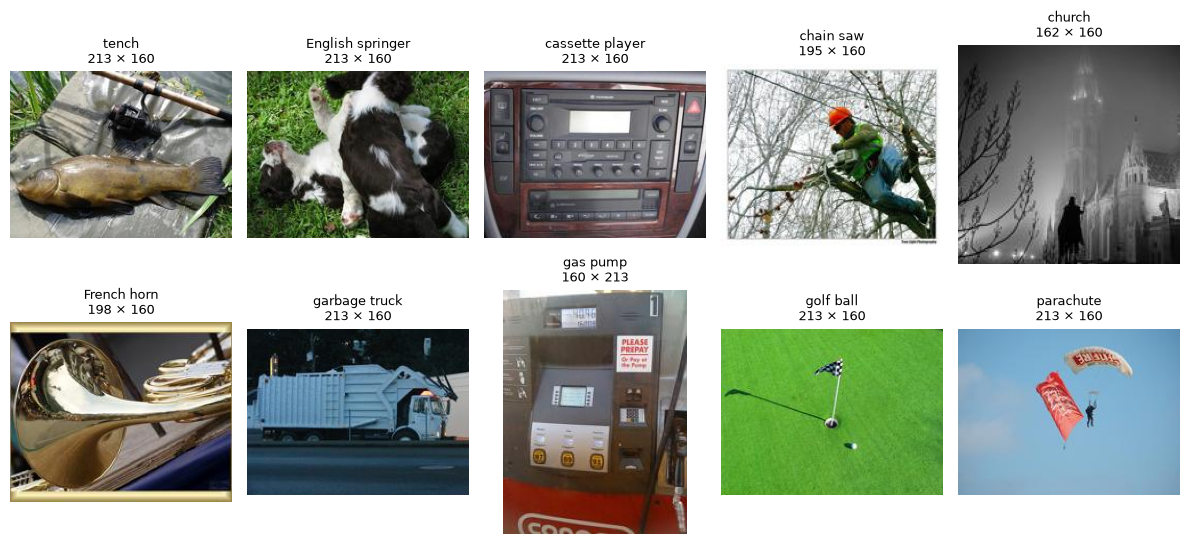

In [2]:
import matplotlib.pyplot as plt
from torchvision import datasets

imagenette = datasets.Imagenette(DATA_DIR, split="val", size="160px", download=True)
class_names = [names[0] for names in imagenette.classes]
val_set = datasets.ImageFolder(DATA_DIR / "imagenette2-160" / "val")
print(f"{len(val_set)} validation images in {len(class_names)} classes")

# The images are sorted by class: the first index of each class.
sample_indices = [val_set.targets.index(c) for c in range(len(class_names))]

fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))
for ax, index in zip(axes.flat, sample_indices):
    image, label = val_set[index]
    ax.imshow(image)
    ax.set_title(f"{class_names[label]}\n{image.width} × {image.height}", fontsize=9)
    ax.axis("off")
fig.tight_layout()
plt.show()

## 3. A pretrained ResNet-18

`models.resnet18(weights=...)` builds the network and downloads weights trained on ImageNet (45 MB). The weights come with the **preprocessing** they were trained with, `weights.transforms()`: resize to 256 pixels, crop the 224 × 224 center, and normalize each color channel with ImageNet's mean and standard deviation. Every image must go through it, or the predictions are wrong.

The network outputs 1,000 scores, one per ImageNet class; `softmax` turns them into probabilities. Below, each image is shown with the network's top guess (green when it matches the Imagenette class), and its top 5 are printed.

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


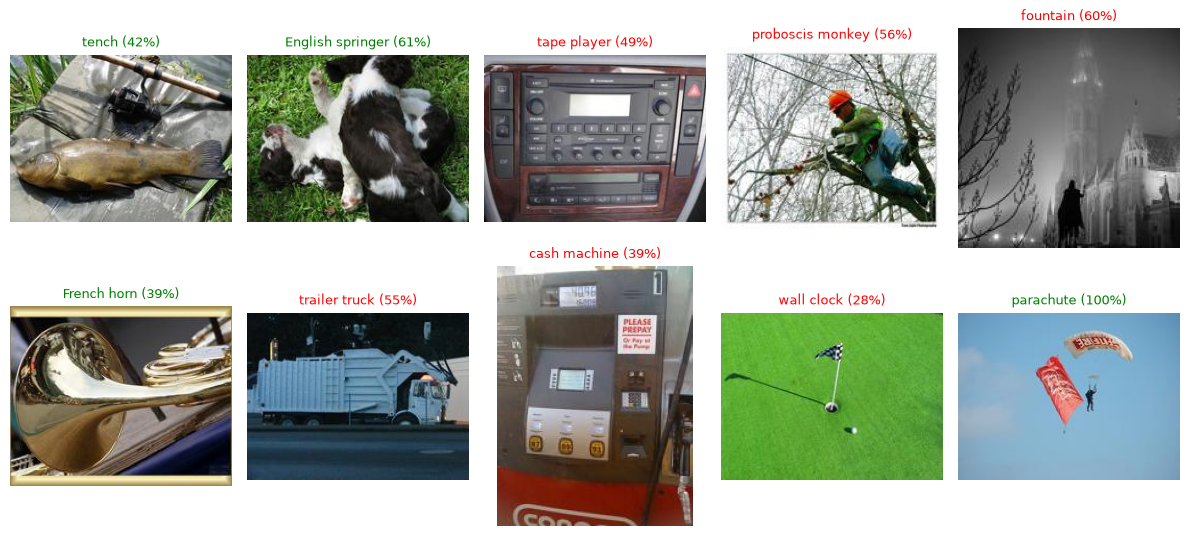

           tench: tench 42%, reel 17%, cannon 7%, barracouta 6%, gar 5%
English springer: English springer 61%, Cardigan 8%, Border collie 5%, cocker spaniel 5%, Tibetan terrier 3%
 cassette player: tape player 49%, cassette player 44%, CD player 7%, radio 0%, cassette 0%
       chain saw: proboscis monkey 56%, black grouse 12%, patas 11%, chain saw 6%, hornbill 6%
          church: fountain 60%, geyser 11%, mosquito net 8%, barn 2%, theater curtain 2%
     French horn: French horn 39%, trombone 19%, cornet 12%, buckle 3%, plane 2%
   garbage truck: trailer truck 55%, garbage truck 29%, moving van 7%, mobile home 3%, tow truck 2%
        gas pump: cash machine 39%, safe 18%, cassette player 9%, tape player 6%, switch 4%
       golf ball: wall clock 28%, safety pin 28%, parachute 9%, golf ball 3%, syringe 2%
       parachute: parachute 100%, airship 0%, balloon 0%, flagpole 0%, umbrella 0%


In [3]:
from torchvision import models

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights).eval().to(device)
preprocess = weights.transforms()
categories = weights.meta["categories"]
print(preprocess)

images = [val_set[i][0] for i in sample_indices]
labels = [val_set[i][1] for i in sample_indices]
batch = torch.stack([preprocess(image) for image in images]).to(device)
with torch.no_grad():
    probs = model(batch).softmax(dim=1).cpu()
top5 = probs.topk(5, dim=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))
for ax, image, label, p, idx in zip(
    axes.flat, images, labels, top5.values, top5.indices
):
    guess = categories[idx[0]]
    ax.imshow(image)
    ax.set_title(
        f"{guess} ({p[0]:.0%})",
        fontsize=9,
        color="green" if guess == class_names[label] else "red",
    )
    ax.axis("off")
fig.tight_layout()
plt.show()

for label, p, idx in zip(labels, top5.values, top5.indices):
    guesses = ", ".join(f"{categories[i]} {q:.0%}" for q, i in zip(p, idx))
    print(f"{class_names[label]:>16}: {guesses}")

## 4. The architecture with `torchinfo`

`torchinfo.summary` runs one fake image through the network and lists every layer with its output shape and its number of parameters. With `depth=2`, it stops at the blocks; try `depth=3` to see inside each block.

| Part | Layers | Output for a 224 × 224 image |
| --- | --- | --- |
| **Stem** | `conv1` (7 × 7, stride 2), `bn1`, `relu`, `maxpool` (stride 2) | 64 × 56 × 56: the image is 4 times smaller after two lines |
| **Stage 1** | `layer1`: 2 `BasicBlock`s | 64 × 56 × 56 |
| **Stage 2** | `layer2`: 2 `BasicBlock`s | 128 × 28 × 28 |
| **Stage 3** | `layer3`: 2 `BasicBlock`s | 256 × 14 × 14 |
| **Stage 4** | `layer4`: 2 `BasicBlock`s | 512 × 7 × 7 |
| **Head** | `avgpool` (average of each 7 × 7 map), `fc` (512 → 1,000) | 1,000 class scores |

Each stage doubles the channels and halves the height and width. A `BasicBlock` is two 3 × 3 convolutions with BatchNorm, plus the skip connection: `output = relu(bn2(conv2(relu(bn1(conv1(x))))) + x)`.

In [4]:
from torchinfo import summary

summary(
    model,
    input_size=(1, 3, 224, 224),
    depth=2,
    col_names=("output_size", "num_params"),
    row_settings=("var_names",),
    device=device,
)

Layer (type (var_name))                  Output Shape              Param #
ResNet (ResNet)                          [1, 1000]                 --
├─Conv2d (conv1)                         [1, 64, 112, 112]         9,408
├─BatchNorm2d (bn1)                      [1, 64, 112, 112]         128
├─ReLU (relu)                            [1, 64, 112, 112]         --
├─MaxPool2d (maxpool)                    [1, 64, 56, 56]           --
├─Sequential (layer1)                    [1, 64, 56, 56]           --
│    └─BasicBlock (0)                    [1, 64, 56, 56]           73,984
│    └─BasicBlock (1)                    [1, 64, 56, 56]           73,984
├─Sequential (layer2)                    [1, 128, 28, 28]          --
│    └─BasicBlock (0)                    [1, 128, 28, 28]          230,144
│    └─BasicBlock (1)                    [1, 128, 28, 28]          295,424
├─Sequential (layer3)                    [1, 256, 14, 14]          --
│    └─BasicBlock (0)                    [1, 256, 14, 14]      

### The first block of a stage

`x` can only be added to the block's output if both have the same shape. Inside a stage they do. But the **first block of stages 2 to 4** changes the shape: its first convolution has `stride=2` (half the height and width) and twice the channels. Its input then goes through a `downsample` shortcut instead: a 1 × 1 convolution with stride 2 (to the new channels and size) and BatchNorm. Every other block adds `x` unchanged (an **identity** shortcut). Compare the two blocks of stage 2:

In [5]:
print("First block of layer2 (changes the shape, has a downsample):")
print(model.layer2[0])
print("\nSecond block of layer2 (identity shortcut, no downsample):")
print(model.layer2[1])

First block of layer2 (changes the shape, has a downsample):
BasicBlock(
  (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (downsample): Sequential(
    (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

Second block of layer2 (identity shortcut, no downsample):
BasicBlock(
  (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 

In [28]:
from torchview import draw_graph
from IPython.display import HTML


graph = draw_graph(
    model,
    input_size=(1, 3, 224, 224),
    expand_nested=True,
    depth=5,
    graph_dir="LR",
)

HEIGHT = 400  # pixels; raise it to make the graph bigger
svg = graph.visual_graph.pipe(format="svg").decode()
svg = svg.replace("<svg ", f'<svg style="height:{HEIGHT}px; width:auto; max-width:none" ', 1)
HTML(f'<div style="overflow-x:auto">{svg}</div>')

## 5. The graph in Netron

[Netron](https://netron.app) draws a network as a graph. The first cell exports ResNet-18 to **ONNX**, a standard file format for networks. Its own optimizer would merge every BatchNorm into the convolution before it, so the cell only folds constants: the graph then shows every layer as above. The skip connections are the `Add` nodes; the `downsample` shortcuts are the side branches with a 1 × 1 `Conv`.

The second cell shows the graph:

- **In Colab**, inside the notebook.
- **Locally**, in a frame and at a link. When the notebook runs on a remote machine (e.g. over SSH in Cursor or VS Code), `localhost` is the remote machine: forward the port first (the **Ports** panel, *Forward a Port*, `8081`), then open the link.
- **Anywhere**: download the `.onnx` file and drop it on [netron.app](https://netron.app); it runs in your browser and uploads nothing.

In [29]:
import warnings

import onnx_ir.passes.common as ir_passes
from onnxscript import optimizer


def export_onnx(net: torch.nn.Module, path: Path) -> Path:
    """Save a network as ONNX, keeping its BatchNorm layers visible."""
    net = net.eval().cpu()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        program = torch.onnx.export(
            net,
            (torch.randn(1, 3, 224, 224),),
            input_names=["image"],
            output_names=["logits"],
            optimize=False,
            verbose=False,
        )
    optimizer.fold_constants(program.model)
    # The exporter gives every convolution without a bias an all-zero one: remove it.
    parameters = dict(net.named_parameters())
    for node in program.model.graph:
        is_conv_with_bias = node.op_type == "Conv" and len(node.inputs) == 3
        if is_conv_with_bias and node.inputs[2].name not in parameters:
            node.resize_inputs(2)
    optimizer.remove_unused_nodes(program.model)
    ir_passes.LiftConstantsToInitializersPass(lift_all_constants=True, size_limit=0)(
        program.model
    )
    program.save(path)
    return path


onnx_path = export_onnx(model, OUTPUT_DIR / "resnet18.onnx")
model.to(device)
print(f"Saved {onnx_path} ({onnx_path.stat().st_size / 1e6:.0f} MB)")

Saved /home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/ResNetWalkThrough/resnet18.onnx (47 MB)


In [33]:
import netron

NETRON_PORT = 8081

if IN_COLAB:
    from google.colab import output

    netron.start(str(onnx_path), address=("0.0.0.0", NETRON_PORT), browse=False)
    output.serve_kernel_port_as_iframe(NETRON_PORT, height="700")
else:
    from IPython.display import IFrame, display

    netron.start(str(onnx_path), address=("localhost", NETRON_PORT), browse=False)
    print(f"Open in a browser: http://localhost:{NETRON_PORT}")
    display(IFrame(f"http://localhost:{NETRON_PORT}", width="100%", height=700))

Serving '/home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/ResNetWalkThrough/resnet18.onnx' at http://localhost:8081


Open in a browser: http://localhost:8081


## 6. Inside Resnet activations and gradients

A **forward hook** is a function PyTorch calls with a layer's output every time the layer runs. The cell below adds one to each layer of the stem and to each of the 8 residual blocks, runs one image through the network, and keeps the outputs. A layer outputs one 2-D map per channel (one per filter), bright where the filter responded; each row shows the layer's **8 most active channels** (highest average value).

What to look for:

- The **stem** keeps the image's shape: its filters respond to edges and colors. `bn1` rescales each channel, `relu` sets negative values to zero (dark), and `maxpool` halves the size.
- Down the stages, the maps get **smaller** (56 → 28 → 14 → 7) and the channels **more abstract**: they respond to parts of the object (an eye, a wheel, a dial), not to edges.
- The last maps (7 × 7) are what `avgpool` averages into the 512 numbers `fc` classifies.

Change `INDEX` to look at another image (0 to 9, one per class).

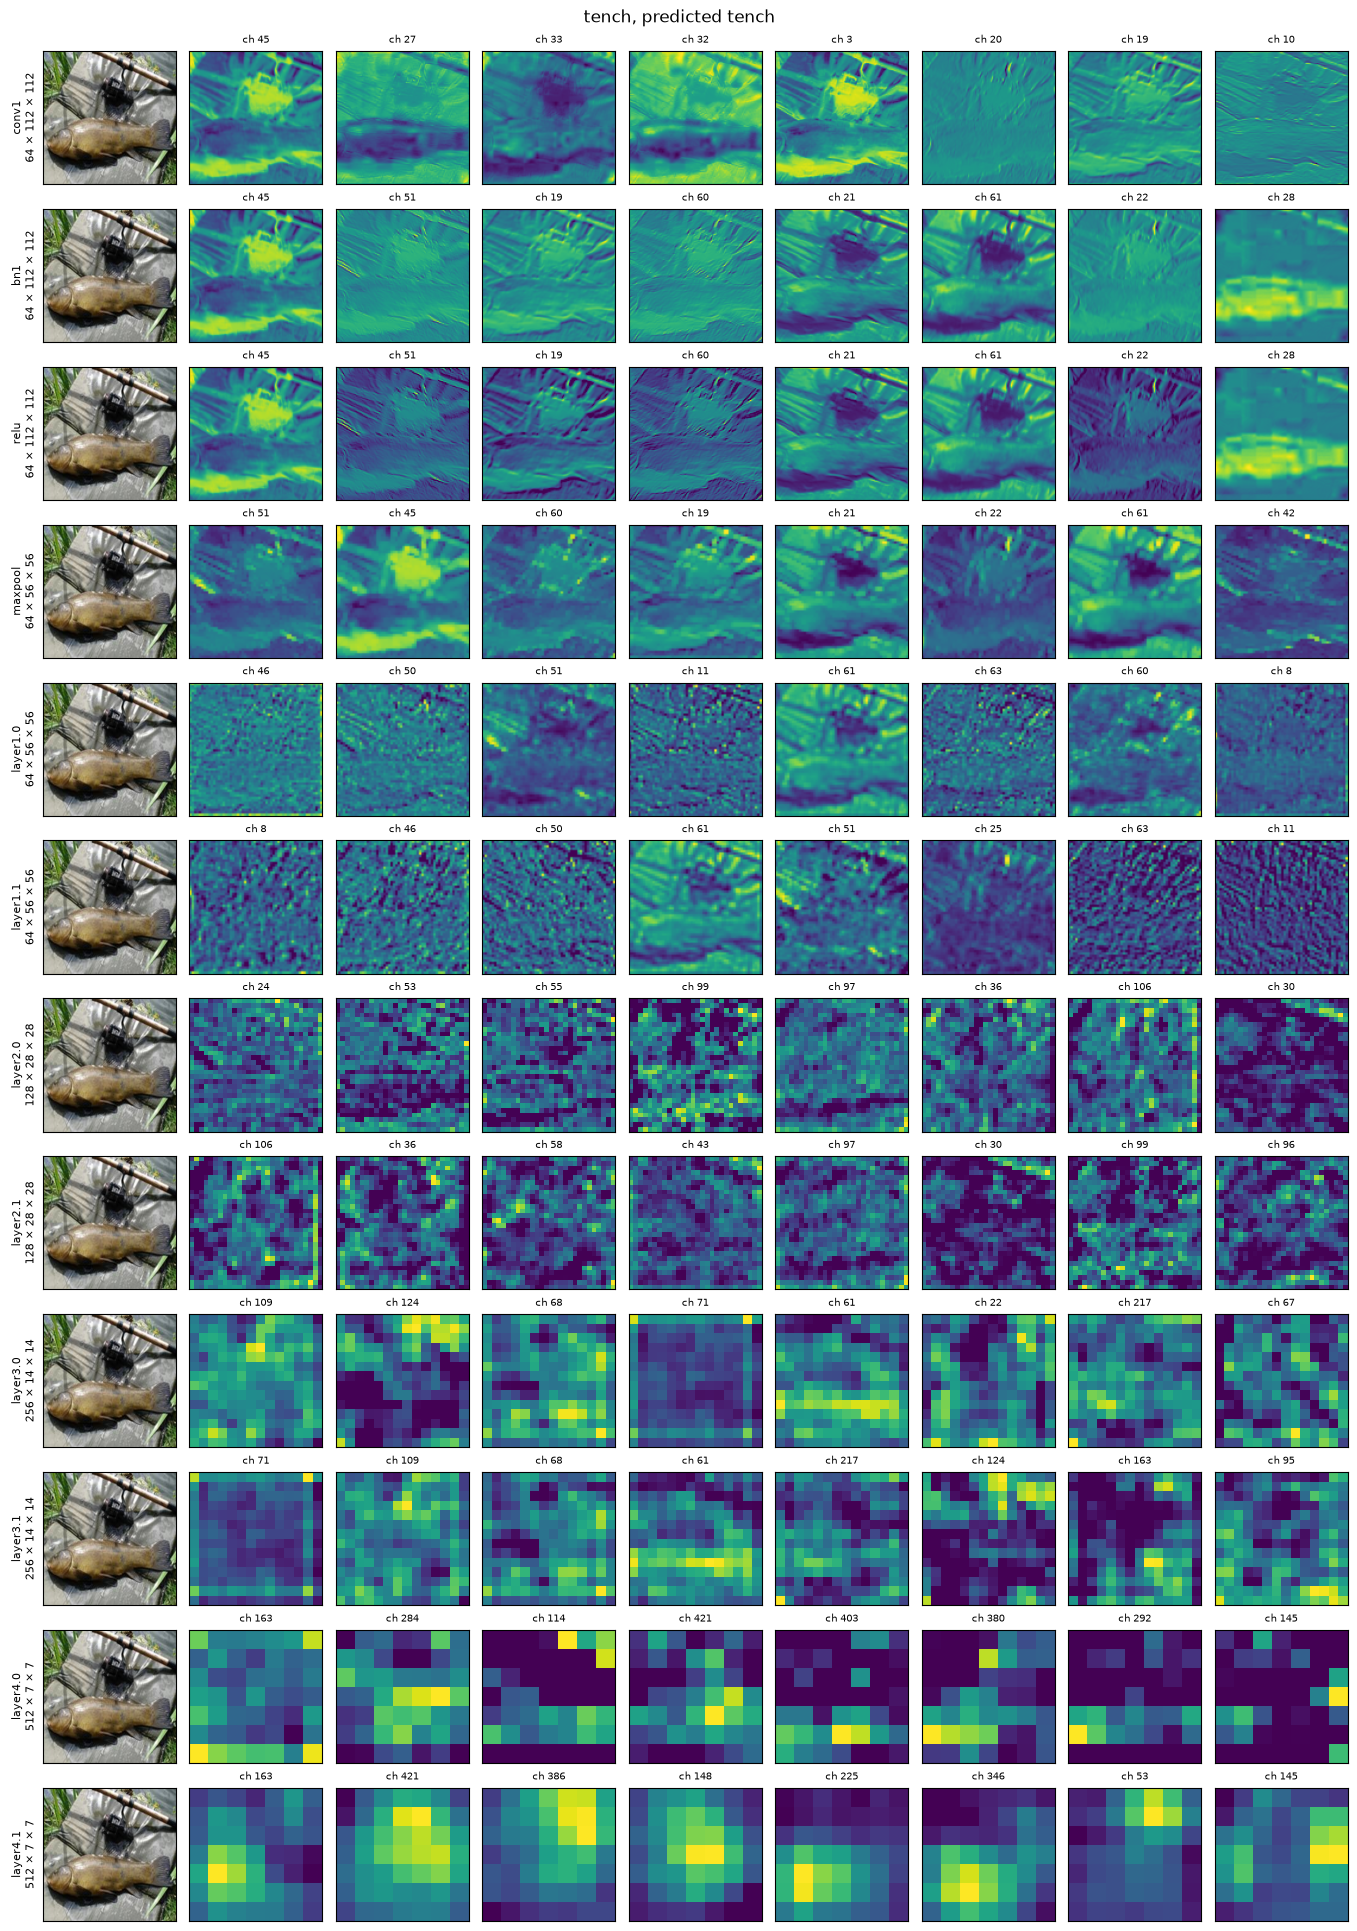

In [34]:
from captum.attr import LayerActivation

INDEX = 0  # one of the 10 sample images
N_CHANNELS = 8

names = ["conv1", "bn1", "relu", "maxpool"]
names += [f"layer{stage}.{b}" for stage in range(1, 5) for b in range(2)]
layers = [model.get_submodule(name) for name in names]

x = batch[INDEX : INDEX + 1]
with torch.no_grad():
    activations = LayerActivation(model, layers).attribute(x)  # one tensor per layer
    pred = model(x).argmax(dim=1).item()

fig, axes = plt.subplots(
    len(names), N_CHANNELS + 1, figsize=(1.5 * (N_CHANNELS + 1), 1.6 * len(names)),
    layout="constrained",
)
for row, name, act in zip(axes, names, activations):
    act = act[0].cpu()  # (channels, height, width)
    row[0].imshow(images[INDEX].resize((224, 224)))
    row[0].set_ylabel(f"{name}\n{' × '.join(map(str, act.shape))}", fontsize=8)
    for ax, channel in zip(row[1:], act.mean(dim=(1, 2)).topk(N_CHANNELS).indices):
        ax.imshow(act[channel], cmap="viridis")
        ax.set_title(f"ch {channel.item()}", fontsize=7)
    for ax in row:
        ax.set_xticks([])
        ax.set_yticks([])
fig.suptitle(f"{class_names[labels[INDEX]]}, predicted {categories[pred]}")
plt.show()

### Inside one block

The first block of stage 2, `layer2[0]`, step by step: its input (64 channels, 56 × 56), the main path (two convolutions, the first with stride 2), the `downsample` shortcut, and the output, `relu(main path + shortcut)`. Rows 2 to 5 show the **same 8 channels** (the most active in the output), so you can follow each channel: the output is bright where the main path, the shortcut, or both are.

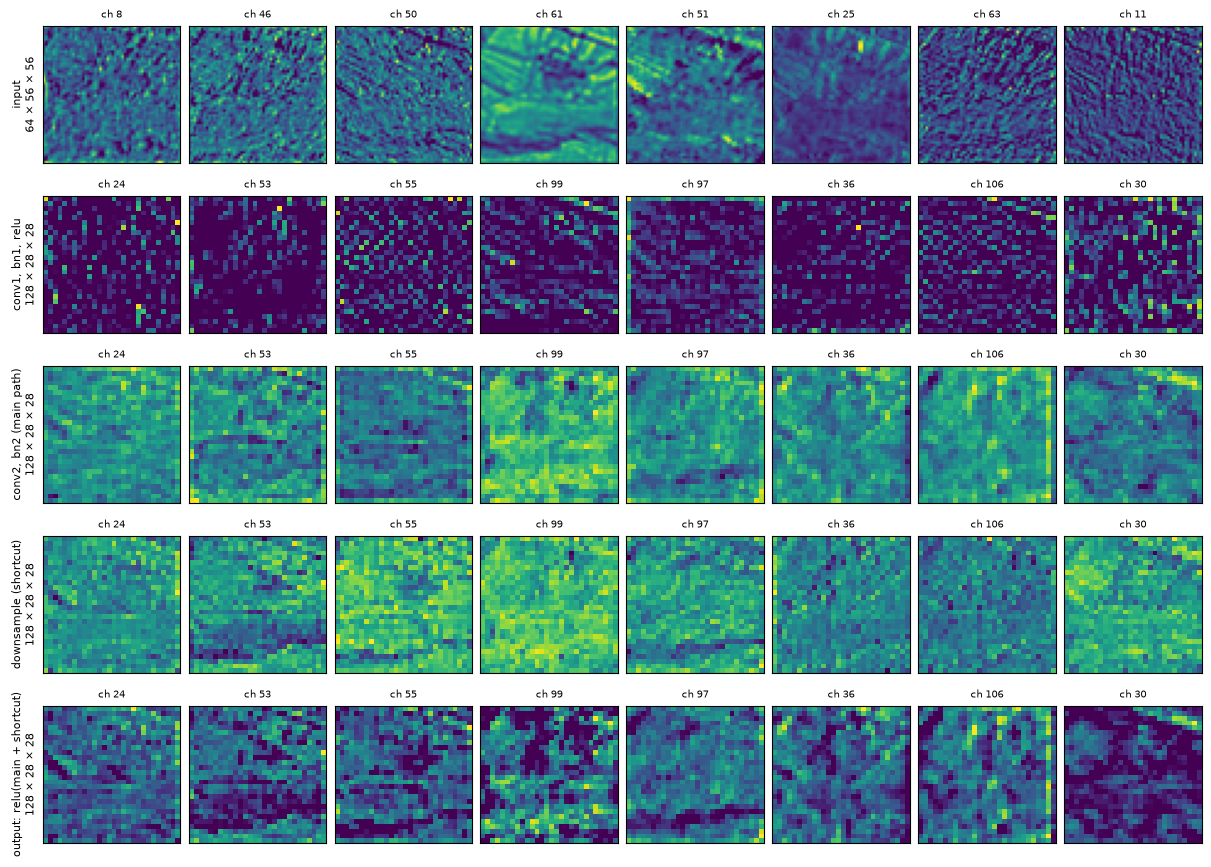

In [38]:
from captum.attr import LayerActivation

block = model.layer2[0]
names = [
    "input",
    "conv1, bn1, relu",
    "conv2, bn2 (main path)",
    "downsample (shortcut)",
    "output: relu(main + shortcut)",
]

x = batch[INDEX : INDEX + 1]
with torch.no_grad():
    block_input = LayerActivation(model, block).attribute(x, attribute_to_layer_input=True)
    bn1, bn2, shortcut, output = LayerActivation(
        model, [block.bn1, block.bn2, block.downsample, block]
    ).attribute(x)
# block.relu runs twice (after bn1 and at the end), so take bn1's output and apply the ReLU here
maps = [t[0].cpu() for t in (block_input, bn1.clamp(min=0), bn2, shortcut, output)]

channels = maps[-1].mean(dim=(1, 2)).topk(N_CHANNELS).indices
fig, axes = plt.subplots(
    len(names), N_CHANNELS, figsize=(1.5 * N_CHANNELS, 1.7 * len(names)), layout="constrained"
)
for row, name, act in zip(axes, names, maps):
    shown = act.mean(dim=(1, 2)).topk(N_CHANNELS).indices if name == "input" else channels
    for ax, channel in zip(row, shown):
        ax.imshow(act[channel], cmap="viridis")
        ax.set_title(f"ch {channel.item()}", fontsize=7)
        ax.set_xticks([])
        ax.set_yticks([])
    row[0].set_ylabel(f"{name}\n{' × '.join(map(str, act.shape))}", fontsize=8)
plt.show()

### Gradient

> Relu Attribution
$$
\text{Grad-CAM} = \mathrm{ReLU}\left( \sum_{\text{channels}} \text{mean}(\text{gradient}) \times \text{activation} \right)
$$

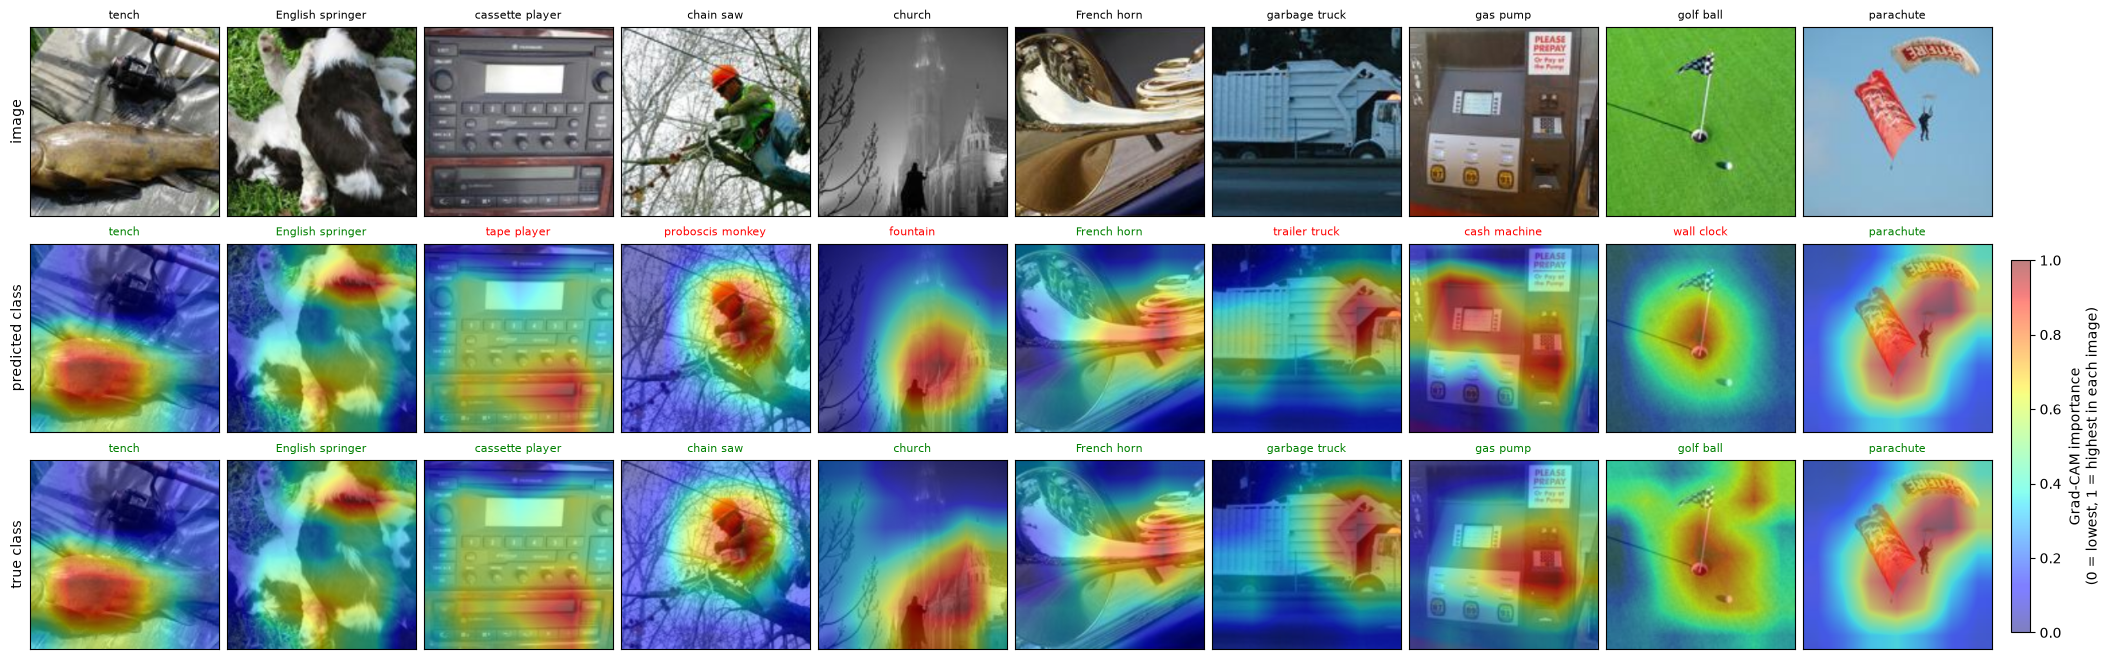

In [60]:
from captum.attr import LayerAttribution, LayerGradCam

CAM_LAYER = model.layer4  # 7 × 7 maps; try model.layer3 for finer 14 × 14 maps

with torch.no_grad():
    preds = model(batch).argmax(dim=1)
true_classes = torch.tensor([categories.index(class_names[c]) for c in labels], device=device)

gradcam = LayerGradCam(model, CAM_LAYER)


def cam_for(targets):
    cam = gradcam.attribute(batch, target=targets, relu_attributions=True)
    cam = LayerAttribution.interpolate(cam, (224, 224), interpolate_mode="bilinear")
    cam = cam[:, 0].detach().cpu()
    low = cam.amin(dim=(1, 2), keepdim=True)
    high = cam.amax(dim=(1, 2), keepdim=True)
    return (cam - low) / (high - low).clamp(min=1e-8)  # each map scaled to 0..1


rows = {"predicted class": (preds, cam_for(preds)), "true class": (true_classes, cam_for(true_classes))}

mean = torch.tensor(preprocess.mean).view(3, 1, 1)
std = torch.tensor(preprocess.std).view(3, 1, 1)
pictures = (batch.cpu() * std + mean).clamp(0, 1).permute(0, 2, 3, 1)  # undo the normalization

fig, axes = plt.subplots(3, len(batch), figsize=(2 * len(batch) + 1, 6.5), layout="constrained")
for i in range(len(batch)):
    axes[0, i].imshow(pictures[i])
    axes[0, i].set_title(class_names[labels[i]], fontsize=8)
    for ax, (targets, cams) in zip(axes[1:, i], rows.values()):
        ax.imshow(pictures[i])
        heatmap = ax.imshow(cams[i], cmap="jet", alpha=0.5, vmin=0, vmax=1)
        right = targets[i] == true_classes[i]
        ax.set_title(categories[targets[i]], fontsize=8, color="green" if right else "red")
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
for ax, name in zip(axes[:, 0], ["image", *rows]):
    ax.set_ylabel(name)
colorbar = fig.colorbar(heatmap, ax=axes[1:, :], shrink=0.9, pad=0.01)
colorbar.set_label("Grad-CAM importance\n(0 = lowest, 1 = highest in each image)")
plt.show()

## 7. ResNet variants

`torchvision` has the whole family. The table builds each network **without** its weights (nothing is downloaded) to count its blocks and parameters; the ImageNet accuracy comes from the weights' metadata.

- **ResNet-18 and 34** use `BasicBlock`s (two 3 × 3 convolutions).
- **ResNet-50, 101, and 152** use `Bottleneck` blocks: a 1 × 1 convolution shrinks the channels, a 3 × 3 convolution works on the smaller tensor, and a 1 × 1 convolution expands them 4 times. Deeper networks for a similar cost: ResNet-50 has 3 times the layers of ResNet-18 but only twice the parameters.
- **ResNeXt** splits the 3 × 3 convolution of each bottleneck into 32 groups (`groups=32`), and **Wide ResNet** doubles the bottleneck's inner channels.

In [57]:
VARIANTS = [
    "resnet18",
    "resnet34",
    "resnet50",
    "resnet101",
    "resnet152",
    "resnext50_32x4d",
    "wide_resnet50_2",
]

print(
    f"{'model':<17} {'block':<11} {'blocks per stage':<17} {'layers':>6} "
    f"{'params':>8} {'top-1':>6} {'weights':>8}"
)
for name in VARIANTS:
    net = models.get_model(name, weights=None)
    meta = models.get_model_weights(name).DEFAULT.meta
    stages = [len(getattr(net, f"layer{s}")) for s in range(1, 5)]
    block_type = type(net.layer1[0]).__name__
    convs_per_block = 2 if block_type == "BasicBlock" else 3
    depth = 2 + convs_per_block * sum(stages)  # conv1 + the blocks' convolutions + fc
    params = sum(p.numel() for p in net.parameters())
    print(
        f"{name:<17} {block_type:<11} {stages!s:<17} {depth:>6} {params / 1e6:>7.1f}M "
        f"{meta['_metrics']['ImageNet-1K']['acc@1']:>5.1f}% {meta['_file_size']:>6.0f}MB"
    )

model             block       blocks per stage  layers   params  top-1  weights
resnet18          BasicBlock  [2, 2, 2, 2]          18    11.7M  69.8%     45MB
resnet34          BasicBlock  [3, 4, 6, 3]          34    21.8M  73.3%     83MB
resnet50          Bottleneck  [3, 4, 6, 3]          50    25.6M  80.9%     98MB
resnet101         Bottleneck  [3, 4, 23, 3]        101    44.5M  81.9%    171MB
resnet152         Bottleneck  [3, 8, 36, 3]        152    60.2M  82.3%    230MB
resnext50_32x4d   Bottleneck  [3, 4, 6, 3]          50    25.0M  81.2%     96MB
wide_resnet50_2   Bottleneck  [3, 4, 6, 3]          50    68.9M  81.6%    263MB


### A bottleneck block

The first block of ResNet-50's stage 1: `conv1` (1 × 1) maps the input to 64 channels, `conv2` (3 × 3) works at 64 channels, and `conv3` (1 × 1) expands them to 256 (4 × 64). In the next blocks, `conv1` shrinks 256 channels back to 64. This first block gets the stem's 64 channels and outputs 256, so it needs a `downsample` shortcut too, with stride 1: the size does not change in stage 1. The ResNet-50 weights (98 MB) are downloaded here; they are used again in the last cell.

In [58]:
resnet50_weights = models.ResNet50_Weights.DEFAULT
resnet50 = models.resnet50(weights=resnet50_weights).eval().to(device)
print(resnet50.layer1[0])
summary(
    resnet50,
    input_size=(1, 3, 224, 224),
    depth=1,
    col_names=("output_size", "num_params"),
    device=device,
)

Bottleneck(
  (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (downsample): Sequential(
    (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          215,808
├─Sequential: 1-6                        [1, 512, 28, 28]          1,219,584
├─Sequential: 1-7                        [1, 1024, 14, 14]         7,098,368
├─Sequential: 1-8                        [1, 2048, 7, 7]           14,964,736
├─AdaptiveAvgPool2d: 1-9                 [1, 2048, 1, 1]           --
├─Linear: 1-10                           [1, 1000]                 2,049,000
Total params: 25,557,032
Trainable params: 25,557,032
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 4.09

### ResNet-18 vs. ResNet-50 on Imagenette

Both networks classify the first 50 validation images of each class (500 images), each with its own preprocessing (ResNet-50's weights were trained with a 232-pixel resize). A prediction counts as right when the top class among the 1,000 is the Imagenette class. The time counts only the forward passes, not the loading of the images. Is ResNet-50's accuracy worth its extra time?

In [59]:
import time

from torch.utils.data import DataLoader, Subset

imagenet_index = [categories.index(name) for name in class_names]
first = [val_set.targets.index(c) for c in range(len(class_names))]
subset = [i for start in first for i in range(start, start + 50)]

for name, net, w in [
    ("ResNet-18", model, weights),
    ("ResNet-50", resnet50, resnet50_weights),
]:
    data = datasets.ImageFolder(val_set.root, transform=w.transforms())
    batches = [
        (x.to(device), y) for x, y in DataLoader(Subset(data, subset), batch_size=50)
    ]
    correct, seconds = 0, 0.0
    with torch.no_grad():
        net(batches[0][0])  # warm-up: the first call on a GPU is slow
        for x, y in batches:
            if device == "cuda":
                torch.cuda.synchronize()
            start = time.perf_counter()
            logits = net(x)
            if device == "cuda":
                torch.cuda.synchronize()
            seconds += time.perf_counter() - start
            pred = logits.argmax(dim=1).cpu()
            correct += (pred == torch.tensor(imagenet_index)[y]).sum().item()
    print(
        f"{name}: {correct / len(subset):.1%} right, "
        f"{seconds / len(subset) * 1000:.2f} ms per image on {device}"
    )

ResNet-18: 65.2% right, 0.08 ms per image on cuda
ResNet-50: 79.0% right, 0.26 ms per image on cuda


## Things to try

- In section 4, run `summary` with `depth=3`, and find the `downsample` of every stage.
- In section 6, look at `INDEX = 4` (church) and `INDEX = 8` (golf ball): which stage first shows the shape of the object?
- Replace `resnet18` with `resnet50` in section 3 and run sections 4 to 6 again: the stages have the same output sizes, but four times the channels.
- Export ResNet-50 in section 5 and find a `Bottleneck` in Netron: the 1 × 1, 3 × 3, 1 × 1 convolutions and their `Add`.
- Add a ResNeXt or a Wide ResNet to the comparison of section 7.